# Quantum Classifier
## Quantum Fashionista
### How to train a hybrid-quantum neural network to classify images of clothes.

In this tutorial you will learn how to create and train a hybrid Convolutional Neural Network (CNN), which uses a Quantum Neural Network (QNN) layer as the final output layer.  
As our training dataset we will use a smaller version of the well known [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset.

## Table of contents:
- [Dataset preparation and exploration](#dataset-preparation)
- [Model creation](#model-building)
- [Model training and evaluation](#model-training-and-results)


In [1]:
import warnings
warnings.simplefilter('ignore')

## Dataset Preparation

### Dataset loading

The Fashion MNIST dataset contains a total of 10 different classes of clothes, but to make our network a bit smaller we will only use 4 of these classes.  
In the cells below we will filter the dataset so that it only contains images of classes: <span style='color:lightblue;'>'t-shirt'</span>,<span style='color:lightblue;'>'trousers'</span>,<span style='color:lightblue;'>'sneakers'</span> and <span style='color:lightblue;'>'bag'</span>

In [2]:
import torchvision # Provides the dataset
import numpy as np #For efficient processing of large number matrices and more advanced math.

interesting_labels = [0,1,7,8]
label_names = ['t-shirt','trousers','sneakers','bag']

fashion_mnist = torchvision.datasets.FashionMNIST('./fmnist',download=True)
dset = [
        (
            np.array(x).astype(np.float32),
            interesting_labels.index(y)
        )
        for x,y in fashion_mnist if y in interesting_labels
    ]

To make our training faster we will only use 100 samples for training and another 100 samples to test our model in the end.

In [3]:
X,y = zip(*dset)
X = np.array(X)[:200]
y = np.array(y)[:200]

X = X[:,np.newaxis,...] #Add a dimension to X.
X.shape,y.shape

((200, 1, 28, 28), (200,))

If you look closely at the code above you might notice that we added a new dimension to X.  
This is because in PyTorch images fed into neural networks are expected to have a shape of $[\text{channels}, \text{width}, \text{height}]$ (e.g $[3, 512, 512]$ for an RGB image of size $512\times512$) and since our images were in grayscale they only had $[\text{width}, \text{height}]$

### Dataset transformation

### Input transformation



Neural networks usually work better with smaller inputs centered around 0.  
Since our inputs were images, any pixel can have a value in range $[0, 255]$, which can negatively affect training.  
One common fix for this issue is *standarization*, which makes our data normally distributed with mean $0$ and standard deviation $1$.

In [4]:
X_mean, X_std = X.mean(), X.std()
print(f"Before transform: X values in range {X.min()} - {X.max()} with mean {X_mean} and standard deviation {X_std}")

X = (X - X_mean)/X_std

print(f"After transform: X values in range {X.min()} - {X.max()} with mean {X.mean()} and standard deviation {X.std()}")

Before transform: X values in range 0.0 - 255.0 with mean 66.94508361816406 and standard deviation 88.08759307861328
After transform: X values in range -0.7599831223487854 - 2.1348626613616943 with mean -7.785096456380813e-10 and standard deviation 1.0


### Target transformation

The output of single class *(input can be only one of n classes)* classifier neural networks is a probability distribution.  
This clashes with our current form of the target variable, which is a whole number in range $[0,3]$.  
To fix this issue we need to represent our target as a probability distribution, which is what **one-hot encoding** is all about.  

#### One-hot encoding
In general when we need to classify $n$ classes, one-hot encoding converts each target variable into a vector of length $n$ with $1$ at the index specified by the target and $0$ everywhere else.  
Examples (assuming 4 classes):
- $0 \rightarrow [1,0,0,0]$
- $1 \rightarrow [0,1,0,0]$
- $2 \rightarrow [0,0,1,0]$
- $3 \rightarrow [0,0,0,1]$


In [5]:
y_onehot = np.zeros((len(y),y.max()+1),dtype=np.float32)
np.put_along_axis(y_onehot,y[np.newaxis].T,1,1)

print(f"Before transform: {y[:4]}")
print(f"After transform:\n{y_onehot[:4]}")

Before transform: [0 0 0 2]
After transform:
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]


### Target classes distribution

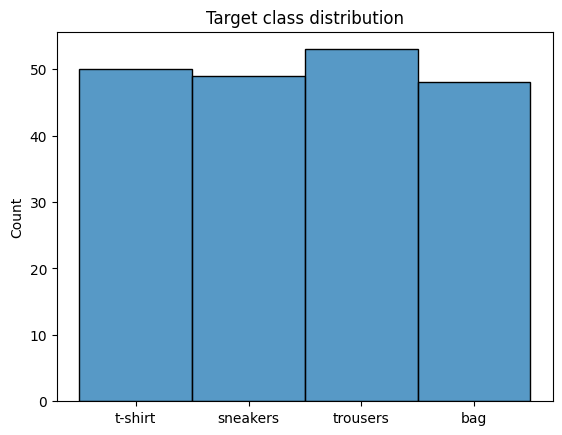

In [6]:
#For creating charts from data.
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot([label_names[y_single] for y_single in y])
plt.title('Target class distribution')
plt.show()

As you can see the distribution of target classes is roughly equal and there are no imbalances.  
This means that the minimum goal of our neural network is to beat the accuracy of $25\%$ (we would get this accuracy by simply picking a random answer each time)

### Sample inputs visualization

Below you can see one example of each class with a corresponding label

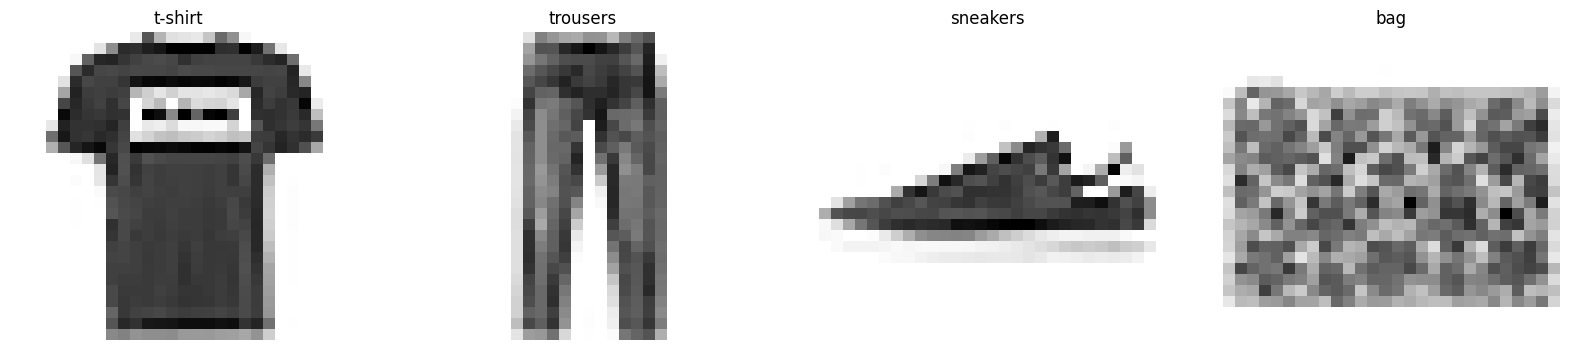

In [7]:
fig = plt.figure(figsize=(20,4))
for i in range(4):
    ax = fig.add_subplot(1,4,i+1)
    first_index = np.where(y == i)[0][0]
    sns.heatmap(X[first_index][0], cmap='Greys',cbar=False,xticklabels=False,yticklabels=False,ax=ax)
    ax.set_title(label_names[y[first_index]])
plt.show()

### Dataset split

Our final action is to split the dataset into 2 subsets: train and test. Our model will only learn from the train dataset and we will evaluate its performance on unseen data with the test dataset.  

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y_onehot,test_size=0.5,shuffle=True,stratify=y_onehot) #Half to train, half to test. Keep the distribution the same with stratification.

## Model building

### Quantum neural network for the quantum layer

In hybrid neural networks, a quantum layer is a pure quantum neural network with its own set of weights, receiving input from the layer above.  
The architectures of QNNs are still heavily researched and an example network is provided below. 

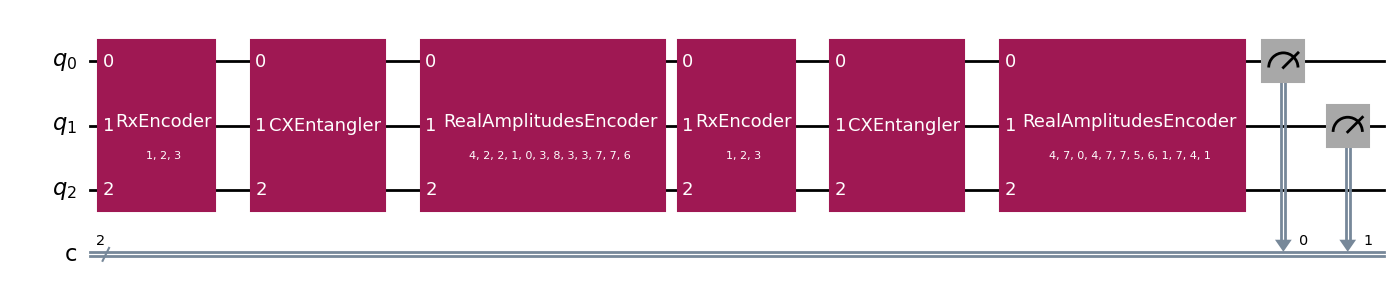

In [9]:
# QNN library integrating with PyTorch
from qailab.circuit import build_circuit, RotationalEncoder, CXEntangler, RealAmplitudesBlock
from qailab.circuit.utils import assign_input_weight

input_encoder = RotationalEncoder('x','input')
qnn_circuit = build_circuit(
    3,
    [
        input_encoder,
        CXEntangler(),
        RealAmplitudesBlock('weight'),
        input_encoder, #You can put the same block twice in different parts of the circuit. It will encode the same parameters
        CXEntangler(),
        RealAmplitudesBlock('weight')
    ],
    measure_qubits=[0,1]
    )

qnn_circuit.assign_parameters(assign_input_weight(qnn_circuit,[1,2,3],np.random.randint(0,9,24))).draw('mpl')

The network is composed of a total of 3 qubits, but measurement is done only on the first two, which gives us an output size of 4 (ideal for our classification task).  
As you can see the network is composed of different blocks, all of which can be seen below in their decomposed form.

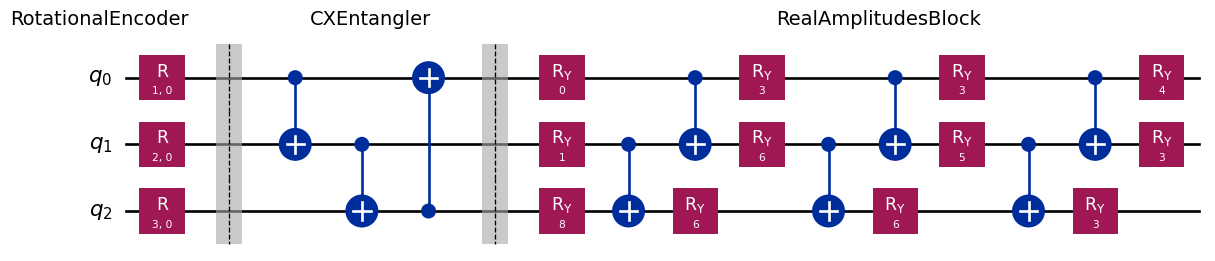

In [10]:
# Quantum circuit library
from qiskit import QuantumCircuit


circuit = QuantumCircuit(3)
RotationalEncoder('x',"input").add_to_circuit(circuit)
circuit.barrier()
CXEntangler().add_to_circuit(circuit)
circuit.barrier()
RealAmplitudesBlock('weight').add_to_circuit(circuit)

fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot()
height = 0.8
ax.text(-2.5, height, 'RotationalEncoder', size=14)
ax.text(2, height, 'CXEntangler', size=14)
ax.text(9, height, 'RealAmplitudesBlock', size=14)

circuit.assign_parameters(assign_input_weight(circuit,[1,2,3],np.random.randint(0,9,12))).decompose().decompose().draw('mpl', ax=ax)

### Hybrid neural network

Our final network will first consist of a few convolutional and max-pooling layers, which will extract interesting features and reduce the size of the image.  
After that, the input is fed into two linear layers, the second of which 'compresses' the shape of the values to fit into our QNN.  
The last layer in our network is the quantum layer, which outputs a distribution of measurements from its quantum circuit.  
After creating the entire network, it is fed into a `QModel` instance, which is a useful wrapper class for PyTorch networks and provides a scikit-learn predictor interface.

In [11]:
# Neural networks libraries
import torch.nn as nn 

from qailab.torch import QLayer,QModel

qlayer = QLayer(qnn_circuit)

sequential_net = nn.Sequential(
    nn.Conv2d(in_channels=1,out_channels=8,kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=8,out_channels=32,kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(800,128),
    nn.ReLU(),
    nn.Linear(128,qlayer.in_features), #QLayers have 2 useful attributes: in_features and out_features, which represent the needed input size and output size
    qlayer
    
)
model = QModel(
    module=sequential_net,
    loss=nn.CrossEntropyLoss(), #Multi-class classification loss
    optimizer_type='adam',
    learning_rate=0.001,
    batch_size=4,
    validation_fraction=0.1,
    epochs=10,
    metric="accuracy"
    )

## Model training and results.

### Training

To train our model we can simply call `QModel.fit()`

In [12]:
model.fit(X_train,y_train)
pass

100%|██████████| 10/10 [07:55<00:00, 47.53s/epochs, acc=1, epoch=10, loss=0.928] 


Below we can see how our model was performing during the 10 epochs of training.

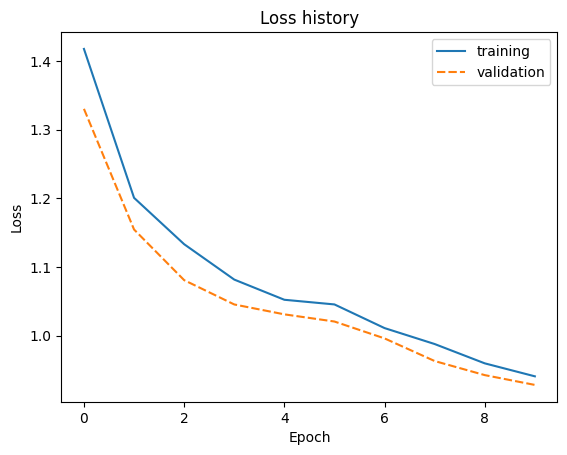

In [13]:
sns.lineplot(model.loss_history)

plt.title('Loss history')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.show()

### Evaluation

Here we will see our model's performance on unseen data using the X_test dataset. We can see the accuracy on the test dataset, as well as which classes are misclassified the most using the confusion matrix.

Test Accuracy:95.0%


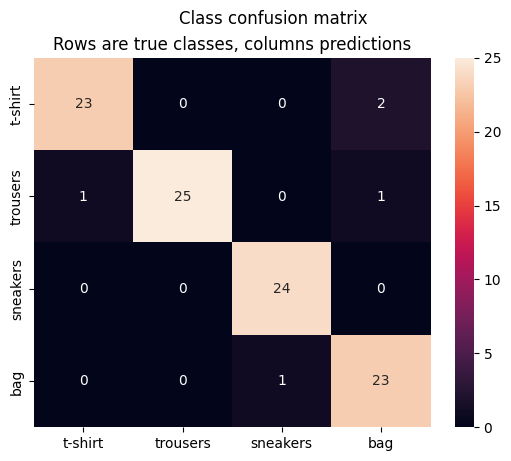

In [14]:
# Data science utility functions
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd #For working with tabular datasets

truth,preds = np.argmax(y_test,axis=1), model.predict(X_test).numpy().argmax(axis=1)
print(f"Test Accuracy:{accuracy_score(truth,preds) * 100}%")

conf_df = pd.DataFrame(confusion_matrix(truth,preds),index=label_names,columns=label_names)
sns.heatmap(conf_df,annot=True)
plt.suptitle("Class confusion matrix")
plt.title("Rows are true classes, columns predictions")
plt.show()